In [1]:
# Import the necessary libraries and the class
from   climateScenario import climateScenario
import matplotlib.pyplot as plt
import pandas as pd

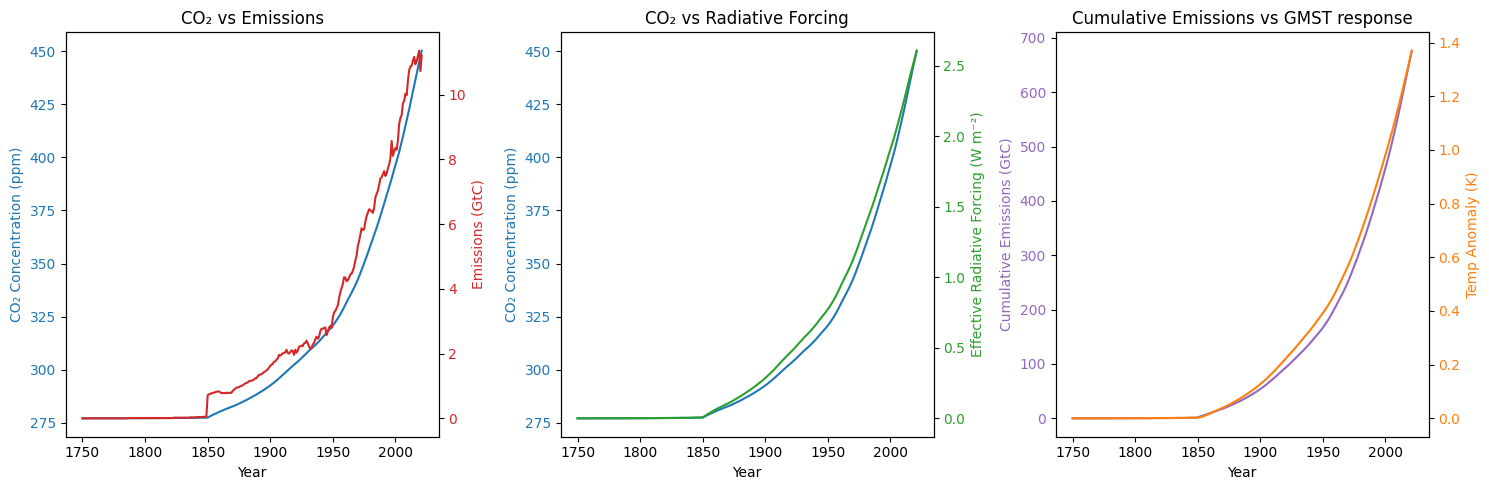

In [ ]:
# climateScenario takes two parameters: emissions (either a preset name or a pd.Series with custom emissions data) and name (optional, for custom scenarios)
# Available 'presets' to choose from: 'historical', 'ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585', 'abrupt-4xCO2', 'pulseCO2'
# 'historical', 'pulseCO2' are emission-driven, the others are concentration-driven (ssps and abrupt-4xCO2 dont have associated emissions)
hist = climateScenario( 'historical' ) # This defines the scenario
hist.integrate()                       # This runs the model
hist.plotOutput()                      # This plots the output

In [3]:
hist.outdf

,emissionsGtC,cumulativeEmissionsGtC,Catm,RF,GMST
Year,,,,,
1750,0.00,0.00,277.150000,0.000000,0.000000
1751,0.00,0.00,277.150000,0.000000,0.000000
1752,0.00,0.00,277.150000,0.000000,0.000000
1753,0.00,0.00,277.150000,0.000000,0.000000
1754,0.00,0.00,277.150000,0.000000,0.000000
...,...,...,...,...,...
2017,11.03,631.98,439.432596,2.473075,1.289569
2018,11.19,643.17,442.148778,2.506997,1.309526
2019,11.36,654.53,444.912165,2.541323,1.329499


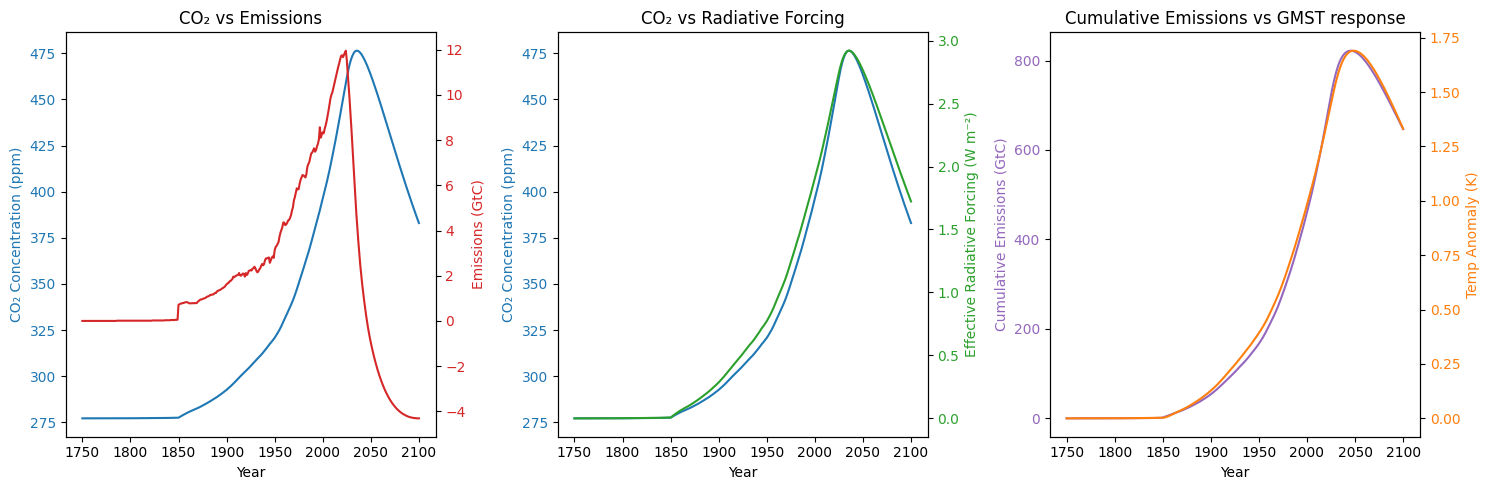

In [4]:
# This is another example with custom emissions data
# I have created the lowest-emissions scenario possible from EnRoads, and using those emissions to drive the model
# We get to negative emissions by end-of-century
# This scenario is cmip7-like in that it explores some very low emissions futures and strong overshoot (I think there will be a scenario like this in cmip7)

emissionfile   = 'https://svante.mit.edu/~pgiani/emissionsdata/cmip7likeScenario.csv'
emissionData   = pd.read_csv( emissionfile, index_col = 0 )
emissionData.rename( columns = {'GtC': 'CO2emissions_GtC'}, inplace = True )
# If no preset is used, the name parameter is required for the scenario and the emissions must be a pd.Series()
customScenario = climateScenario( emissions = emissionData['CO2emissions_GtC'], name = 'netzero_cmip7like' )
customScenario.integrate()
customScenario.plotOutput()
plt.show()


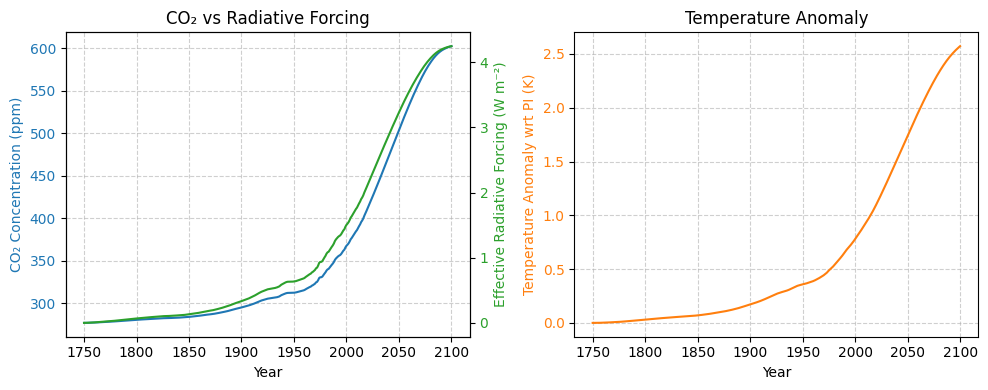

In [5]:
# Finally an example of concentration-driven scenario (ssp245)
ssp245 = climateScenario( 'ssp245' ) # This defines the scenario
ssp245.integrate()                   # This runs the model
ssp245.plotOutput()                  # This plots the output

In [16]:
# The link with the diffusion model could be something like this:
################
# Input begins #
year  = 2075
month = 3
scenario_selection = 'ssp245'
## Input ends
################

scenario = climateScenario( scenario_selection )
scenario.integrate()
gmst  = scenario.outdf.loc[ year, 'GMST' ]
print( f"In year {year}, under the {scenario_selection} scenario, the GMST anomaly is {gmst:.2f} °C... Using that for diffusion model" )
# ... diffusion model code here ...

In year 2075, under the ssp245 scenario, the GMST anomaly is 2.25 °C... Using that for diffusion model
